<a href="https://colab.research.google.com/github/samuelorozco641/Seminario_Ciencia_Datos/blob/main/Laboratorio1_Incremento1_SamuelOrozco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt #libreria nos permite graficar
import seaborn as sns #libreria nos permite graficar estadistica

In [3]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [4]:
ruta = "/content/drive/MyDrive/SEMINARIO CIENCIA DE DATOS/Laboratorios/dataset_banco.csv"

data = pd.read_csv(ruta)

# **Taller incremento 1**

# **PARTE 1**

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


In [6]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [7]:
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45215.000000,45213.000000,45215.000000,45214.000000,45215.000000,45214.000000,45215.000000
mean,41.004711,1374.159866,15.805839,258.074357,2.763729,40.192485,0.580383
std,12.036647,3924.255525,8.322473,257.605175,3.097910,100.120622,2.303438
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


1.   **¿Cuántas observaciones y variables tiene el dataset?**
* El dataset tiene 45.203 observaciones y 17 variables.


2.   **¿Qué tipos de variables tiene el dataset?**
* Las variables son de tipo int64, float64 y object.

3.   **¿Cuál crees que es la variable más importante y por qué?**
* La variable mas importante en mi opinion sería **duration** ya que existe una correlación muy fuerte entre la duración de la llamada y si el cliente acepta el producto.De la misma dor si una llamada dura mucho tiempo, normalmente significa que el cliente está interesado o está discutiendo el producto, lo que aumenta mucho la probabilidad de conversión.

4.   **¿Qué variables parecen tener escalas muy diferentes?**
* La variable de duration y balance tienen valores muy amplios.

5.   **¿Qué variables podrían requerir transformación?**
* Las variables que podrían requerir transformación son **balance**, **duration**, **pdays**, **campaign** y **previous**, ya que presentan escalas muy diferentes, distribuciones sesgadas, presencia de valores extremos o valores especiales que pueden afectar el rendimiento de algunos modelos de análisis o aprendizaje automático. Transformarlas ayuda a reducir la influencia de outliers, corregir la asimetría de las distribuciones y hacer que las variables sean más comparables entre sí, lo que facilita el entrenamiento de modelos y mejora la estabilidad y la interpretabilidad de los resultados.

6.   **¿Qué información no puedes obtener solo con describe()?**
* El describe() no muestra la distribución completa de los datos ni su forma asimetrica o multimodalidad, las relaciones o correlaciones entre variables, la presencia y naturaleza de valores atípicos de forma visual

7.   **¿Por qué describe() no muestra variables categóricas?**
* Esto pasa por que describe() está precisamente diseñado para presentar solo un resumen de variables númericas.

8.   **¿Qué variable podría generar problemas si se analiza solo con promedios?**
* balance y duration presentan un rango muy amplio por lo que pueden estar sesgadas y no presentar los valores reales si es que se tratan como promedios.

In [8]:
data['y'].value_counts()
data['y'].value_counts(normalize=True)

,proportion
y,
no,0.883003
yes,0.116997


1.   **¿Cuál es la clase mayoritaria?**
* La clase mayoritaria es 'no', con el 88% de las observaciones.

2.   **¿Qué porcentaje representa la clase minoritaria?**
* La clase minoritaria es 'yes', con el 12% de las observaciones.

3.   **¿Este comportamiento es realista en campañas bancarias?**
* Sí, es realista. En muchas campañas de marketing las tasas de conversión suelen ser bajas. En alguna de ellas los clientes no aceptan la oferta.

4.   **¿Qué riesgo existe si ignoramos la clase minoritaria?**
* Podria tener varios riesgos como por ejemplo se refleja en las métricas engañosas o modelos sesgados.

5.   **¿Un dataset balanceado siempre representa mejor la realidad?**
* No necesariamente. En algunas ocasiones el balancear un dataset puede llegar a distorsionar los resultados.

6.   **¿Qué decisiones del negocio podrían verse afectadas por este desbalance?**
* De las decisiones clave se verían afectadas la asignacion de recursos, la creación de campañas futuras. la rentabilidad o la segmentación de clientes por ejemplo.

7.   **¿Qué variable podría estar relacionada con la clase “yes”?**
* Algunas pueden ser job, age, education, balance o duration.

# **Parte 2**

In [9]:
data.isnull().sum()

,0
age,0
job,2
marital,1
education,1
default,0
balance,2
housing,0
loan,0
contact,0
day,0


1. **¿Qué variables tienen valores faltantes?**
* **job:** 2 **marital:** 1 **education:** 1 **balance:** 2 **duration:** 1 y **pdays:** 1.

2. **¿Qué porcentaje del dataset representan?**
* De las 45215 filas, "job" y "balance" representan aproximadamente 0.0044% cada uno, y "marital", "education", "duration" y "pdays" representan el 0.0022% cada uno.

3. **¿Hay variables críticas con datos faltantes?**
* No existen variables críticas con datos faltantes. Las variables con valores nulos son pocas

4. **¿Eliminarías filas con NA? ¿Por qué?**
* Justamente por tener pocos datos faltantes si conviene eliminarlos, no afectaria mucho

5. **¿Qué información podrías perder?**
* Se perderían los valores de las 8 filas que cuentan con valores nulos.

6. **¿Imputarías todos los NA con la misma técnica?**
* No siempre es buena idea ya que a veces los datos que se manejan son de distinto tipo por lo que pueden requerir técnicas de manejo distinto para limpiarlos correctamente.

7. **¿Eliminar NA podría introducir sesgo?**
* Depende, puede llegar a pasar si los faltantes no son aleatorios, pero en este caso el riesgo es muy bajo por la cantidad baja de valores faltantes.

8. **¿Qué tipo de clientes podrían quedar fuera del análisis?**
* Los que estén asociados a valores nulos.

9. **¿Esto afectaría la representatividad del dataset?**
* No afectaría de forma tan relevante ya que la propórción de datos eliminados es tan baja que no tendría mucha afectacion

In [10]:
data.duplicated().sum()

np.int64(4)

1. **¿Existen duplicados?**
* Existen 4 filas duplicadas en el dataset.

2. **¿Un duplicado siempre es un error?**
* Un dato duplicado no siempre es un error, muchas veces depende del contexto. Ya que a veces estos pueden representar eventos que en realidad se repitieron.

3. **¿Qué información adicional necesitarías para decidir?**
* Para decidir sobre eliminar registros duplidos, es prudente saber primero la naturaleza de los datos, ya que algunas pueden representar entidades únicas o enventos, tambien la fuente de los datos, o las columnas clave.

4. **¿Qué pasaría si eliminamos registros válidos?**
* Si se eliminan registros validos, al final de los analisis se podrian llegar a ver valores incorrectos, ya que si no se tienen la totalidad de los datos correctos desde un inico, los calculos posteriores pueden mostrar valores erroneos.

<Axes: xlabel='balance'>

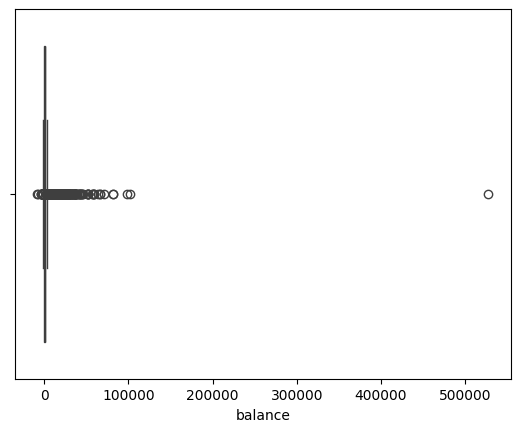

In [11]:
import seaborn as sns
sns.boxplot(x=data['balance'])

1.   **¿Existen valores extremos?**
* Sí, se muestra claramente muchos puntos individuales por encima del bigote superior y por debajo del bigote inferior, lo que indica la presencia de numerosos valores extremos.

2.   **¿Son positivos, negativos o ambos?**
* Son **ambos**. Hay un gran número de valores extremos positivos, como balances altos y también valores extremos negativos, que representan deudas o cuentas sobregiradas.

3.   **¿El boxplot te permite ver todos los detalles?**
* No, un boxplot es una excelente herramienta para visualizar la distribución y detectar outliers de forma general, pero no muestra los detalles de la información.

4.   **¿Cómo afectan los outliers a la media?**
* Los outliers, especialmente los muy extremos, afectan significativamente a la media, sesgándola. En el caso de balance, los valores extremadamente altos tiran la media hacia arriba, y los valores muy negativos la tiran hacia abajo. En este caso la media está considerablemente más alta que la mediana, lo que sugiere que hay outliers positivos que la están elevando, haciéndola menos representativa del "balance típico".

5.   **¿La mediana se ve afectada?**
* La mediana es mucho más robusta y se ve mínimamente afectada por los outliers. Como la mediana es el valor central de un conjunto de datos ordenado, su posición no cambia drásticamente incluso si hay valores extremos en los límites del dataset.

6.   **¿Qué estadístico sería más confiable aquí?**
* Debido a la presencia de outliers significativos, la mediana sería un estadistico de tendencia central más confiable para balance que la media.

7.   **¿Eliminarías los outliers? Justifica.**
* No seria bueno eliminarlos sin un análisis previo muy cuidadoso. Solamente se podria hacer esto si por ejemplo son datos reales pero inusuales, o errores de entrada o datos con un impacto demasiado elevado para el modelo.

8.   **¿Podrían representar clientes reales?**
* Si, un balance de alto podría ser un cliente de alto valor, y un balance de bajo podría ser un cliente con una deuda importante.

9.   **¿Qué riesgos existen al eliminarlos sin análisis?**
* Eliminar outliers sin comprenderlos conlleva riesgos importantes, como la perdida de informacion valiosa, o sesgos en el analisis y los modelos ya que no representarian la realidad tan fielmente, lo que podría llevar a tomar decisiones de negocios erroneas.

# **CONCLUSIÓN**

El análisis exploratorio del dataset permite identificar varias características importantes de las variables antes de aplicar cualquier modelo.

A partir de las estadísticas descriptivas se observa que algunas variables presentan escalas muy diferentes, lo que puede afectar ciertos algoritmos si no se aplican técnicas de normalización o estandarización. También se identifican variables con distribuciones sesgadas y presencia de valores extremos, como balance o duration, que pueden distorsionar medidas como el promedio. Por esta razón, en algunos casos es necesario aplicar transformaciones que ayuden a estabilizar la variabilidad de los datos. Asimismo, se detectan variables que contienen valores especiales o codificaciones particulares, como pdays, que requieren interpretación antes de analizarlas.

Otra limitación importante es que el método describe() solo proporciona estadísticas resumidas, por lo que no permite entender completamente la forma de las distribuciones ni las relaciones entre variables. Por ello, es necesario complementar el análisis con visualizaciones y otras técnicas exploratorias.

En conjunto, este proceso permite comprender mejor la estructura del dataset y detectar posibles problemas de calidad o escala. Realizar estas revisiones iniciales facilita la preparación de los datos y contribuye a construir modelos más robustos y confiables.

# **¿Está el dataset listo para modelar? ¿Por qué?**

El dataset aún no se encuentra completamente preparado para ser utilizado en un proceso de modelado, ya que presenta varios aspectos críticos que deben atenderse antes de construir un modelo predictivo. En primer lugar, es importante aplicar un tratamiento adecuado a los valores faltantes; aunque su cantidad sea reducida, es recomendable gestionarlos correctamente para evitar posibles sesgos en el análisis. En segundo lugar, la presencia de registros duplicados requiere una revisión contextual para determinar si corresponden a errores en los datos o si representan eventos legítimos.

Por último, la existencia de valores atípicos en variables puede influir de manera significativa en el comportamiento de los algoritmos de machine learning, por lo que es necesario evaluarlos y aplicar estrategias apropiadas para su manejo antes del entrenamiento del modelo.

# **Que tipos de Modelos se pueden aplicar al Dataset Bancario?**

Se pueden utilizar modelos de clasificación, como la regresión logística, debido a su facilidad de interpretación, y árboles de decisión, que permiten trabajar tanto con variables categóricas como numéricas y además capturar relaciones no lineales entre las variables.

Asimismo, también es posible aplicar técnicas de agrupamiento (clustering), las cuales resultan útiles para segmentar a los clientes según sus características y así identificar distintos perfiles dentro del conjunto de datos.